In [48]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import json


In [49]:
path = '/content/News_Category_Dataset_v3.json'

valid_lines = []
for line in open(path, 'r'):
    try:
        valid_lines.append(json.loads(line))
    except:
        continue  # skip malformed lines

df = pd.DataFrame(valid_lines)

In [50]:
# Step 3: EDA (Exploration)
print(df.head())
print(df['category'].value_counts())
print(df.isnull().sum())

                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Until you have a dog y

In [51]:
# Step 4: Cleaning and Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)                     # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()             # remove extra whitespace
    return text

df['clean_headline'] = df['headline'].apply(clean_text)

In [52]:
# Step 5: Encode Categorical Variables
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
num_classes = df['label'].nunique()
print(f"Number of Classes: {num_classes}")

# Save Label Encoder for later use
joblib.dump(le, 'label_encoder.pkl')

Number of Classes: 42


['label_encoder.pkl']

In [53]:
# Step 6: Tokenization and Sequence Padding
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_headline'])
vocab_size = len(tokenizer.word_index) + 1
print(f"Vocabulary Size: {vocab_size}")

# Save Tokenizer
joblib.dump(tokenizer, 'tokenizer.pkl')

sequences = tokenizer.texts_to_sequences(df['clean_headline'])
max_length = max(len(seq) for seq in sequences)
print(f"Max headline length: {max_length}")

X = pad_sequences(sequences, maxlen=max_length, padding='post')
y = df['label'].values

Vocabulary Size: 70039
Max headline length: 43


In [54]:
# Step 7: Split Data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train size: {X_train.shape}, Val size: {X_val.shape}, Test size: {X_test.shape}")


Train size: (146668, 43), Val size: (31429, 43), Test size: (31430, 43)


In [55]:
# Step 8: Build the CNN Model
embedding_dim = 100

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Step 9: Train the Model
early_stop = EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/5
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 143s 124ms/step - accuracy: 0.8178 - loss: 0.6254 - val_accuracy: 0.5322 - val_loss: 2.5022
Epoch 2/5
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 207s 129ms/step - accuracy: 0.8581 - loss: 0.4795 - val_accuracy: 0.5244 - val_loss: 2.8006
Epoch 3/5
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 149s 130ms/step - accuracy: 0.8859 - loss: 0.3785 - val_accuracy: 0.5150 - val_loss: 3.1755
Epoch 4/5
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 189s 119ms/step - accuracy: 0.9062 - loss: 0.3088 - val_accuracy: 0.5101 - val_loss: 3.5278


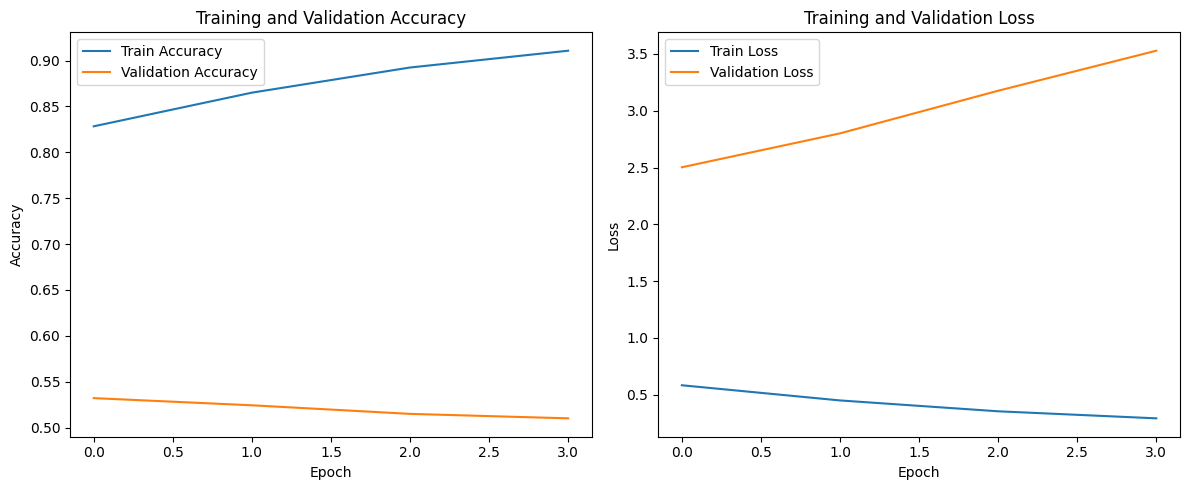

In [58]:
# Step 10: Plot Training and Validation Curves
# Plot accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [59]:
# Step 11: Evaluate on Test Data
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

983/983 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5109 - loss: 3.5299

Test Accuracy: 0.5109


In [60]:
# Step 12: Detailed Classification Report
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))


983/983 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
                precision    recall  f1-score   support

          ARTS       0.24      0.21      0.22       226
ARTS & CULTURE       0.21      0.10      0.14       201
  BLACK VOICES       0.39      0.36      0.38       688
      BUSINESS       0.41      0.35      0.38       899
       COLLEGE       0.29      0.32      0.31       171
        COMEDY       0.37      0.38      0.37       810
         CRIME       0.43      0.47      0.45       535
CULTURE & ARTS       0.32      0.18      0.23       161
       DIVORCE       0.67      0.63      0.65       514
     EDUCATION       0.29      0.22      0.25       152
 ENTERTAINMENT       0.57      0.63      0.60      2605
   ENVIRONMENT       0.31      0.23      0.26       216
         FIFTY       0.16      0.15      0.15       210
  FOOD & DRINK       0.60      0.61      0.61       951
     GOOD NEWS       0.11      0.11      0.11       209
         GREEN       0.27      0.24      0.26       394
HEALTH

In [61]:
# ⏩ Step 13: User Input Prediction
def predict_category(headline):
    clean_headline = clean_text(headline)
    seq = tokenizer.texts_to_sequences([clean_headline])
    padded = pad_sequences(seq, maxlen=max_length, padding='post')
    pred = model.predict(padded)
    pred_class = np.argmax(pred, axis=1)[0]
    category = le.inverse_transform([pred_class])[0]
    return category

while True:
    user_input = input("\nEnter a news headline to predict its category (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break
    predicted_category = predict_category(user_input)
    print(f"Predicted Category: {predicted_category}")


Enter a news headline to predict its category (or type 'exit' to quit): Global South Pushes Back on Green Colonialism Amid Just Energy Transition Framework Talks
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted Category: POLITICS

Enter a news headline to predict its category (or type 'exit' to quit): AI Governance Gaps Exposed as Multilateral Efforts Stumble Over Ethical Enforcement Protocols
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Category: IMPACT

Enter a news headline to predict its category (or type 'exit' to quit): exit
